## Segmentation Models Comparative Analysis

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import scienceplots
plt.style.use(['science',"no-latex"])

In [11]:
# 1. Define Paths using pathlib
DATA_DIR = Path().cwd().parents[1] / "data" / "metrics"
OUTPUT_DIR = Path(".")

In [18]:
# Load the segmentation dataset
csv_path = DATA_DIR / "segmentation_models.csv"
df_seg = pd.read_csv(csv_path)

# Sort models by performance metric for clearer charting
df = df_seg.sort_values(by="validationMeanIoU", ascending=True)

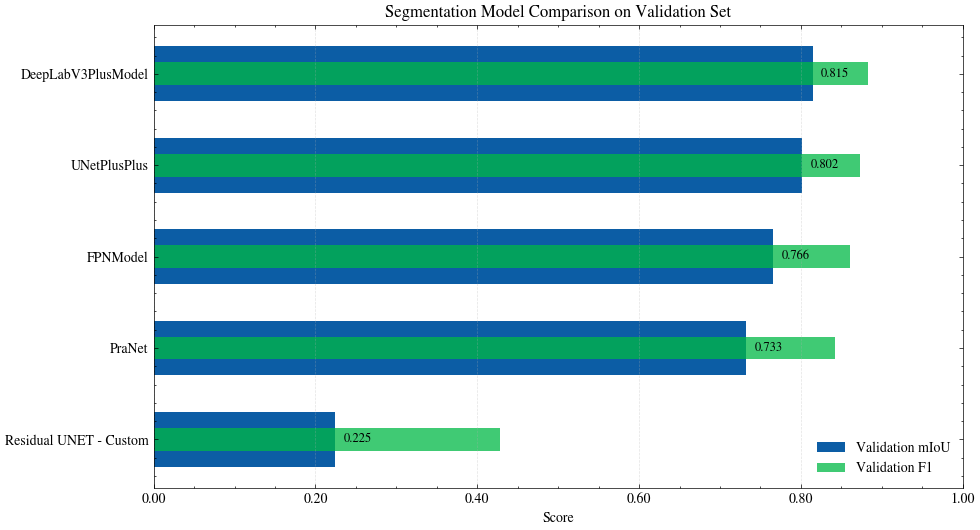

In [23]:
fig, ax = plt.subplots(figsize=(10, 5.5))

y = np.arange(len(df))
bars = ax.barh(y, df["validationMeanIoU"], height=0.6, label="Validation mIoU")
ax.barh(y, df["validationF1Score"], height=0.25, label="Validation F1", alpha=0.75)

ax.set_yticks(y)
ax.set_yticklabels(df["modelName"])
ax.set_xlabel("Score")
ax.set_title("Segmentation Model Comparison on Validation Set")
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(loc="lower right")

for i, v in enumerate(df["validationMeanIoU"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_ranked_validation_miou.png", bbox_inches="tight")
plt.show()

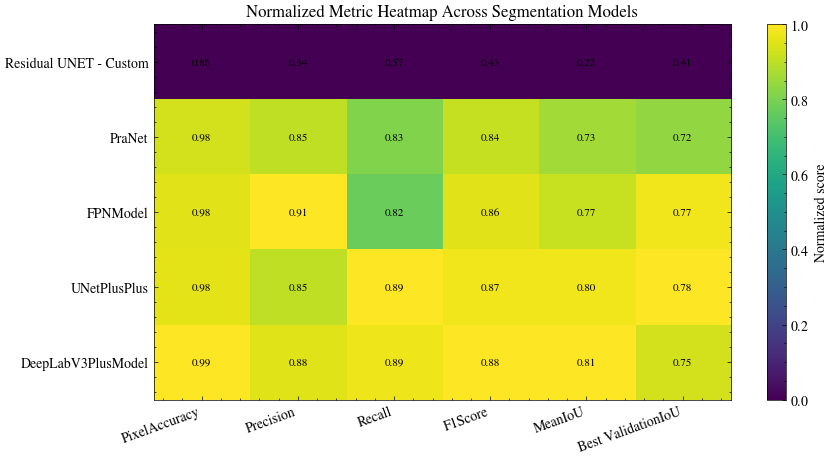

In [ ]:
metrics = [
    "validationPixelAccuracy",
    "validationPrecision",
    "validationRecall",
    "validationF1Score",
    "validationMeanIoU",
    "bestValidationIoU",
]

heat = df.set_index("modelName")[metrics].copy()

# Optional: normalize per metric for visual comparison
heat_norm = (heat - heat.min()) / (heat.max() - heat.min())

fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(heat_norm.values, aspect="auto")

ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(
    [m.replace("validation", "").replace("best", "Best ") for m in metrics],
    rotation=20,
    ha="right",
)
ax.set_yticks(np.arange(len(heat_norm.index)))
ax.set_yticklabels(heat_norm.index)

ax.set_title("Normalized Metric Heatmap Across Segmentation Models")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized score")

# annotate raw values
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig2_metric_heatmap.png", bbox_inches="tight")
plt.show()

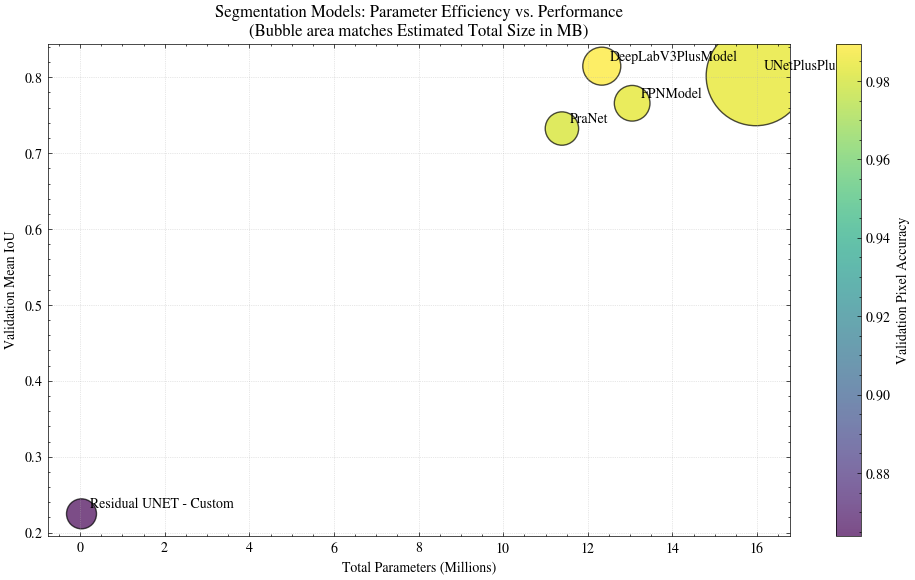

In [17]:
# 3. Plot 2: Efficiency Trade-off (Total Parameters vs. Performance)
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Bubble sizes correspond to Estimated Model Size (MB), color represents overall Pixel Accuracy
scatter2 = ax2.scatter(
    df_seg["totalParams"] / 1e6,
    df_seg["validationMeanIoU"],
    s=df_seg["estimatedTotalSizeMb"] * 5,
    c=df_seg["validationPixelAccuracy"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black",
)

# Label points with model names
for idx, row in df_seg.iterrows():
    ax2.annotate(
        row["modelName"],
        (row["totalParams"] / 1e6, row["validationMeanIoU"]),
        xytext=(6, 4),
        textcoords="offset points",
    )

ax2.set_xlabel("Total Parameters (Millions)")
ax2.set_ylabel("Validation Mean IoU")
ax2.set_title(
    "Segmentation Models: Parameter Efficiency vs. Performance\n(Bubble area matches Estimated Total Size in MB)"
)
cbar2 = fig2.colorbar(scatter2, ax=ax2)
cbar2.set_label("Validation Pixel Accuracy")
ax2.grid(linestyle=":", alpha=0.6)

plt.tight_layout()
fig2.savefig(OUTPUT_DIR / "segmentation_efficiency_tradeoff.png", dpi=300)
plt.show()

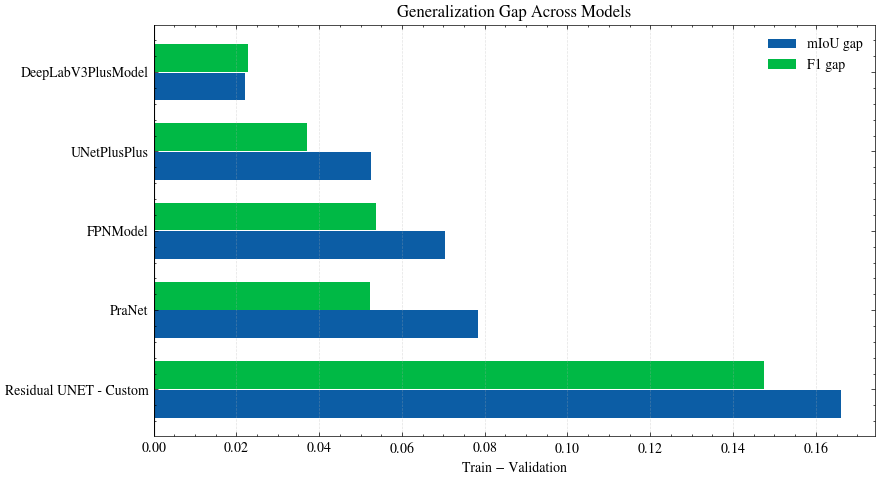

In [26]:
df["miou_gap"] = df["trainMeanIoU"] - df["validationMeanIoU"]
df["f1_gap"] = df["trainF1Score"] - df["validationF1Score"]

fig, ax = plt.subplots(figsize=(9, 5))

y = np.arange(len(df))
ax.barh(y - 0.18, df["miou_gap"], height=0.35, label="mIoU gap")
ax.barh(y + 0.18, df["f1_gap"], height=0.35, label="F1 gap")

ax.set_yticks(y)
ax.set_yticklabels(df["modelName"])
ax.set_xlabel("Train − Validation")
ax.set_title("Generalization Gap Across Models")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.legend()

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig4_generalization_gap.png", bbox_inches="tight")
plt.show(fig)